## Importing ***PySpark***

In [2]:
# importing pyspark
from pyspark.sql import SparkSession 

### Spark session started

In [3]:
spark = (
    SparkSession.builder
    .appName("Test")
    .config("spark.master", "local[*]")
    .getOrCreate()
)

print("Spark Session Created")

Spark Session Created


## **Module 1**: Data Loading & Schema Handling
#### Task 1: Load all CSV files into PySpark DataFrames


In [4]:
# country_wise_latest.csv
df_country_wise_latest = spark.read.csv(
    "archive/country_wise_latest.csv",
    header = True,
    inferSchema = True
)

# covid_19_clean_complete.csv
df_covid_19_clean_complete = spark.read.csv(
    "archive/covid_19_clean_complete.csv",
    header = True,
    inferSchema = True
)

# day_wise.csv
df_day_wise = spark.read.csv(
    "archive/day_wise.csv",
    header = True,
    inferSchema = True
)

# fully_grouped.csv
df_full_grouped = spark.read.csv(
    "archive/full_grouped.csv",
    header = True,
    inferSchema = True
)

# usa_county_wise.csv
df_usa_county_wise = spark.read.csv(
    "archive/usa_county_wise.csv",
    header = True,
    inferSchema = True
)

# worldometer_data.csv
df_worldometer_data = spark.read.csv(
    "archive/worldometer_data.csv",
    header = True,
    inferSchema = True
)


#### Diplaying the dataframes

In [5]:
# country_wise_latest.csv
print("\ncountry_wise_latest.csv","\n")
print(df_country_wise_latest.show(5))

# covid_19_clean_complete.csv
print("-"*90,"\ncovid_19_clean_complete.csv\n")
print(df_covid_19_clean_complete.show(5))

# day_wise.csv
print("-"*90,"\nday_wise.csv\n")
print(df_day_wise.show(5))

# full_grouped.csv
print("-"*90,"\nfull_grouped.csv\n")
print(df_full_grouped.show(5))

# usa_county_wise.csv
print("-"*90,"\nusa_county_wise.csv\n")
print(df_usa_county_wise.show(5))

# worldometer_data.csv
print("-"*90,"\nworldometer_data.csv\n")
print(df_worldometer_data.show(5))



country_wise_latest.csv 

+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|Country/Region|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|Confirmed last week|1 week change|1 week % increase|          WHO Region|
+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|   Afghanistan|    36263|  1269|    25198|  9796|      106|        10|           18|               3.5|                69.49|                  5.04|              35526|          737|             2.07|Eastern Mediterra...|
|       Albania|     4880|   144|     2745|  1991|      117|         6|          

#### Displaying Schemas

In [6]:
# country_wise_latest.csv
print("\ncountry_wise_latest.csv","\n")
df_country_wise_latest.printSchema()

# covid_19_clean_complete.csv
print("-"*90,"\ncovid_19_clean_complete.csv\n")
df_covid_19_clean_complete.printSchema()

# day_wise.csv
print("-"*90,"\nday_wise.csv\n")
df_day_wise.printSchema()

# full_grouped.csv
print("-"*90,"\nfull_grouped.csv\n")
df_full_grouped.printSchema()

# usa_county_wise.csv
print("-"*90,"\nusa_county_wise.csv\n")
df_usa_county_wise.printSchema()

# worldometer_data.csv
print("-"*90,"\nworldometer_data.csv\n")
df_worldometer_data.printSchema()


country_wise_latest.csv 

root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: string (nullable = true)
 |-- Confirmed last week: integer (nullable = true)
 |-- 1 week change: integer (nullable = true)
 |-- 1 week % increase: double (nullable = true)
 |-- WHO Region: string (nullable = true)

------------------------------------------------------------------------------------------ 
covid_19_clean_complete.csv

root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable =

#### Displaying Row Count

In [7]:
# country_wise_latest.csv
print(f"{'country_wise_latest.csv':<30} : {df_country_wise_latest.count():>10}")

# covid_19_clean_complete.csv
print(f"{'covid_19_clean_complete.csv':<30} : {df_covid_19_clean_complete.count():>10}")

# day_wise.csv
print(f"{'day_wise.csv' :<30} : {df_day_wise.count() :>10}")

# full_grouped.csv
print(f"{'full_grouped.csv' :<30} : {df_full_grouped.count():>10}")

# usa_county_wise.csv
print(f"{'usa_county_wise.csv':<30} : {df_usa_county_wise.count() :>10}")

# worldometer_data.csv
print(f"{'worldometer_data.csv':<30} : {df_worldometer_data.count():>10}")




country_wise_latest.csv        :        187
covid_19_clean_complete.csv    :      49068
day_wise.csv                   :        188
full_grouped.csv               :      35156
usa_county_wise.csv            :     627920
worldometer_data.csv           :        209


## **Module 2** : Data Cleaning Tasks

#### **Task 2** : Handle Missing Province/State Values


In [8]:
from pyspark.sql.functions import*

In [9]:
# Checking null values in Province/State column
df_null_province = df_covid_19_clean_complete.filter(col("Province/State").isNull())

# Country-wise NULL count report
country_null_report = (
    df_covid_19_clean_complete
    .filter(col("Province/State").isNull())
    .groupBy("Country/Region")
    .count()
    .withColumnRenamed("count", "Null Province Count")
    .orderBy(desc("Null Province Count"))
)

# Replace NULL Province/State values with "Unknown"
df_covid_19_clean_complete = df_covid_19_clean_complete.fillna({"Province/State": "Unknown"})

print("Cleaned data")
df_covid_19_clean_complete.filter(col("Province/State") == "Unknown").show(10, truncate=False)

Cleaned data
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State|Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Unknown       |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|Unknown       |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown       |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|Unknown       |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown       |Angola             |-11.2027|17.8739  |2020-01-22|0        |0     |0        |0     |Africa               |
|Un

#### **Task 3** : Standardize Country Names

In [10]:
# Step 1 : Find Country Name Inconsistencies

# Get distinct country names from all datasets
full_countries = df_full_grouped.select("Country/Region").distinct()
latest_countries = df_country_wise_latest.select("Country/Region").distinct()
worldometer_countries = df_worldometer_data.select("Country/Region").distinct()

# Countries present in full_grouped but NOT present in country_wise_latest
full_countries.subtract(
    latest_countries
).show(truncate=False)

# Countries present in worldometer_data but NOT present in full_grouped
worldometer_countries.subtract(
    full_countries
).show(truncate=False)


# Step 2 : Define Standardization Rules
country_mappings = {
    "US": "USA",
    "S. Korea": "South Korea",
    "UK": "United Kingdom",
    "UAE": "United Arab Emirates",
    "Taiwan*": "Taiwan",
    "Korea, South": "South Korea"
}

# Step 3 : Function to Standardize Country Names
def standardize_country_names(df):
    # Remove extra spaces from beginning/end
    df = df.withColumn(
        "Country/Region",
        regexp_replace(
            col("Country/Region"),
            "^\\s+|\\s+$",
            ""
        )
    )

    # Apply standardization rules
    country_column = col("Country/Region")
    for old_name, new_name in country_mappings.items():
        country_column = when(
            country_column == old_name,
            new_name
        ).otherwise(country_column)

    # Update column
    df = df.withColumn(
        "Country/Region",
        country_column
    )
    return df


# Step 4 : Apply Standardization
df_full_grouped = standardize_country_names(df_full_grouped)
df_country_wise_latest = standardize_country_names(df_country_wise_latest)
df_worldometer_data = standardize_country_names(df_worldometer_data)

+--------------+
|Country/Region|
+--------------+
+--------------+

+----------------------+
|Country/Region        |
+----------------------+
|Macao                 |
|CAR                   |
|Turks and Caicos      |
|Ivory Coast           |
|Montserrat            |
|Taiwan                |
|Caribbean Netherlands |
|New Caledonia         |
|Myanmar               |
|Martinique            |
|Cayman Islands        |
|Isle of Man           |
|Réunion               |
|S. Korea              |
|Guadeloupe            |
|St. Vincent Grenadines|
|Curaçao               |
|Congo                 |
|Hong Kong             |
|Brunei                |
+----------------------+
only showing top 20 rows


In [11]:
# Step 5 : Verify old inconsistent names
old_names = [
    "US",
    "S. Korea",
    "UK",
    "UAE",
    "Taiwan*",
    "Korea, South"
]
print("checking inconsistency")
df_full_grouped.filter(col("Country/Region").isin(old_names)).select("Country/Region").distinct().show(truncate=False)


# Step 6 : Verify NEW standardized names
new_names = [
    "USA",
    "South Korea",
    "United Kingdom",
    "United Arab Emirates",
    "Taiwan"
]

df_full_grouped.filter(col("Country/Region").isin(new_names)).select("Country/Region").distinct().show(truncate=False)

checking inconsistency
+--------------+
|Country/Region|
+--------------+
+--------------+

+--------------------+
|Country/Region      |
+--------------------+
|Taiwan              |
|USA                 |
|South Korea         |
|United Arab Emirates|
|United Kingdom      |
+--------------------+



#### **Task 4** : Remove Duplicate Daily Records


In [12]:
# Step 1 : Check Duplicate Records Based on Country + Date

duplicate_records = (df_covid_19_clean_complete.groupBy("Country/Region", "Date").count().filter(col("count") > 1))
print("Duplicate Country + Date Records\n")
duplicate_records.show(truncate=False)

# Step 2 : Count Duplicate Groups
duplicate_count = duplicate_records.count()
print(f"\nTotal Duplicate Groups : {duplicate_count}")

# Step 3 : Store Row Count BEFORE Cleaning
before_duplicate_removal = df_covid_19_clean_complete.count()
print(f"Rows Before Removing Duplicates : {before_duplicate_removal}")

# Step 4 : Remove Duplicate Records
df_clean_complete_no_duplicates = (
    df_covid_19_clean_complete
    .dropDuplicates(["Country/Region", "Date"])
)
after_duplicate_removal = (
    df_clean_complete_no_duplicates.count()
)

print(f"Rows After Removing Duplicates : {after_duplicate_removal}")

# Step 7 : Verify Duplicates Removed
remaining_duplicates = (
    df_clean_complete_no_duplicates
    .groupBy("Country/Region", "Date")
    .count()
    .filter(col("count") > 1)
)

print("Remaining Duplicate Records\n")
remaining_duplicates.show(truncate=False)

# 
# Step 8 : Cleaned Dataset Sample
df_clean_complete_no_duplicates.show(10, truncate=False)

Duplicate Country + Date Records

+--------------+----------+-----+
|Country/Region|Date      |count|
+--------------+----------+-----+
|China         |2020-05-01|33   |
|Netherlands   |2020-06-08|4    |
|Australia     |2020-06-10|8    |
|Denmark       |2020-06-21|2    |
|United Kingdom|2020-07-03|11   |
|Netherlands   |2020-04-20|4    |
|Australia     |2020-05-10|8    |
|Australia     |2020-07-16|8    |
|United Kingdom|2020-05-03|11   |
|Australia     |2020-05-14|8    |
|Australia     |2020-05-29|8    |
|China         |2020-06-06|33   |
|Netherlands   |2020-07-12|4    |
|France        |2020-07-13|11   |
|Canada        |2020-07-25|12   |
|Denmark       |2020-07-25|2    |
|China         |2020-01-28|33   |
|Denmark       |2020-02-25|2    |
|Australia     |2020-05-01|8    |
|France        |2020-05-27|11   |
+--------------+----------+-----+
only showing top 20 rows

Total Duplicate Groups : 1316
Rows Before Removing Duplicates : 49068
Rows After Removing Duplicates : 35156
Remaining Dupli

## **Module 3** : Aggregation Tasks


#### **Task 5** : Top 10 Countries by Total Confirmed Cases


+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+



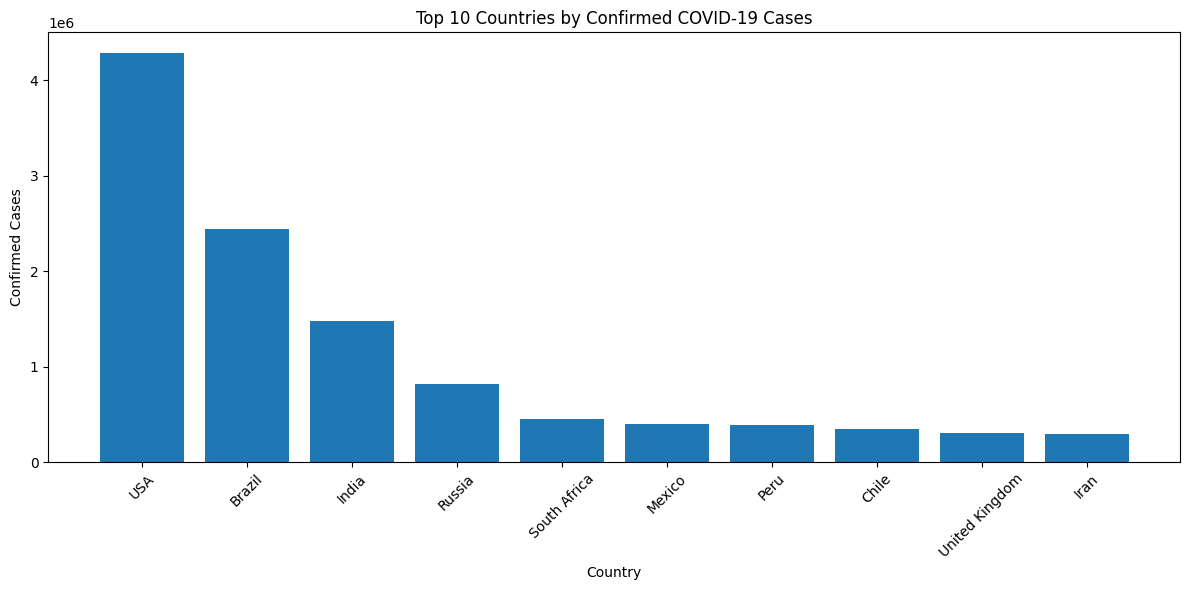

In [13]:
# Step 1 : Select Required Columnn
df_confirmed_cases = df_country_wise_latest.select(
    "Country/Region",
    "Confirmed"
)

# Step 2 : Sort Countries by Confirmed Cases
df_top_confirmed_cases = (
    df_confirmed_cases
    .orderBy(
        desc("Confirmed")
    )
)

# Step 3 : Extract Top 10 Countries
df_top_10_confirmed_cases = (
    df_top_confirmed_cases
    .limit(10)
)

# Step 4 : Convert to Pandas DataFrame
df_top_10_confirmed_cases_pandas = (
    df_top_10_confirmed_cases.toPandas()
)

df_top_10_confirmed_cases.show(truncate=False)

# Step 5 : Bar Chart Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    df_top_10_confirmed_cases_pandas["Country/Region"],
    df_top_10_confirmed_cases_pandas["Confirmed"]
)
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.tight_layout()
plt.show()

#### **Task 6** : Top 10 Countries by Death Rate


In [19]:
# Step 1 : Select Required Columns
df_death_rate = df_country_wise_latest.select(
    "Country/Region",
    "Deaths",
    "Confirmed"
)

# Step 2 : Calculate Death Rate
df_death_rate = (df_death_rate.withColumn("Death Rate",round((col("Deaths") / col("Confirmed")) * 100,2)))

# Step 3 : Sort by Death Rate
df_death_rate_sorted = (df_death_rate.orderBy(desc("Death Rate")))

# Step 4 : Extract Top 10 Countries
df_top_10_death_rate = (df_death_rate_sorted.limit(10))

# Step 5 : Display Final Output
print("=" * 75)
print(f"{'Country':<30}{'Deaths':>12}{'Confirmed':>15}{'Death Rate %':>15}")
print("=" * 75)
for row in df_top_10_death_rate.collect():
    print(f"{row['Country/Region']:<30}{row['Deaths']:>12,}{row['Confirmed']:>15,}{row['Death Rate']:>15}")
print("=" * 75)


Country                             Deaths      Confirmed   Death Rate %
Yemen                                  483          1,691          28.56
United Kingdom                      45,844        301,708          15.19
Belgium                              9,822         66,428          14.79
Italy                               35,112        246,286          14.26
France                              30,212        220,352          13.71
Hungary                                596          4,448           13.4
Netherlands                          6,160         53,413          11.53
Mexico                              44,022        395,489          11.13
Spain                               28,432        272,421          10.44
Western Sahara                           1             10           10.0


#### **Task 7** : WHO Region-wise Total Cases


In [30]:
# Step 1 : Group by WHO Region
df_who_region_cases = (
    df_full_grouped
    .groupBy("WHO Region")
    .agg(
        sum("Confirmed").alias("Total Confirmed"),
        sum("Deaths").alias("Total Deaths"),
        sum("Recovered").alias("Total Recovered")
    )
)

# Step 2 : Sort by Total Confirmed Cases
df_who_region_cases = df_who_region_cases.orderBy(col("Total Confirmed").desc())

# Step 4 : Convert to Pandas DataFrame
df_who_region_cases_pandas = (
    df_who_region_cases.toPandas()
)

In [ ]:
df_who_region_cases_pandas

,WHO Region,Total Confirmed,Total Deaths,Total Recovered
0,Americas,402261194,19359292,157069444
1,Europe,248879793,19271040,123202075
2,Eastern Mediterranean,74082892,1924029,48050703
3,South-East Asia,55118365,1458134,30030327
4,Western Pacific,26374411,932430,18861950
5,Africa,21791827,439978,11193730


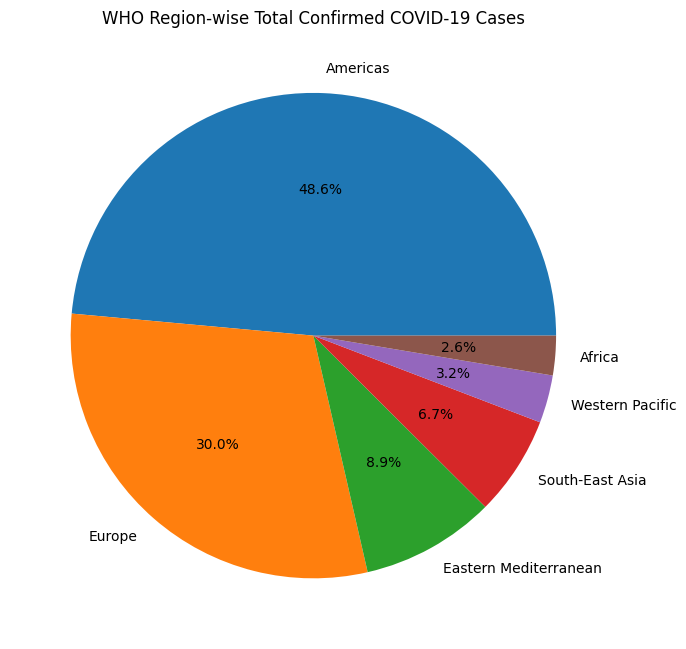

In [35]:
# Step 5 : Pie Chart Visualization : Total Confirmed Cases by WHO Region
plt.figure(figsize=(7, 7))
plt.pie(
    df_who_region_cases_pandas["Total Confirmed"],
    labels=df_who_region_cases_pandas["WHO Region"],
    autopct="%1.1f%%"
)
plt.title("WHO Region-wise Total Confirmed COVID-19 Cases")
plt.tight_layout()
plt.show()